In [1]:
import pyrootutils
root = pyrootutils.setup_root(
    search_from=".",
    indicator=".git",
    pythonpath=True,
    dotenv=True,
)

# Simulation Quality Comparison Results

This notebook visualizes the comparison between NegBinCopula, AE+Diffusion, scVI-Posterior, and scVI-Prior approaches across different numbers of highly variable genes.

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# Load results from JSON file (new location with metadata)
with open(str(root / 'experiments' / 'outputs' / 'sim_benchmarking_results' / 'tabula_muris' / 'comparison_results.json'), 'r') as f:
    data = json.load(f)

# Extract metadata and results
metadata = data['metadata']
results_list = data['results']

print("Results loaded successfully!")
print(f"Dataset: {metadata['dataset']}")
print(f"Number of cells: {metadata['n_cells']}")
print(f"Simulators tested: {', '.join(metadata['simulators'])}")
print(f"Number of gene configurations: {len(results_list)}")
print(f"Timestamp: {metadata['timestamp']}")

# Extract data into arrays
n_genes = [r['n_genes'] for r in results_list]

# Extract results for each simulator
nbc_auc = [r.get('negbincopula_auc', float('nan')) for r in results_list]
nbc_acc = [r.get('negbincopula_acc', float('nan')) for r in results_list]

ae_diff_auc = [r.get('ae_diffusion_auc', float('nan')) for r in results_list]
ae_diff_acc = [r.get('ae_diffusion_acc', float('nan')) for r in results_list]

scvi_post_auc = [r.get('scvi_posterior_auc', float('nan')) for r in results_list]
scvi_post_acc = [r.get('scvi_posterior_acc', float('nan')) for r in results_list]

scvi_prior_auc = [r.get('scvi_prior_auc', float('nan')) for r in results_list]
scvi_prior_acc = [r.get('scvi_prior_acc', float('nan')) for r in results_list]

print(f"\nGene counts: {n_genes}")

Results loaded successfully!
Dataset: tabula_muris
Number of cells: 10000
Simulators tested: negbincopula, ae_diffusion, scvi_posterior, scvi_prior
Number of gene configurations: 4
Timestamp: 2026-03-17T16:10:25.492580

Gene counts: [1000, 2000, 4000, 8000]


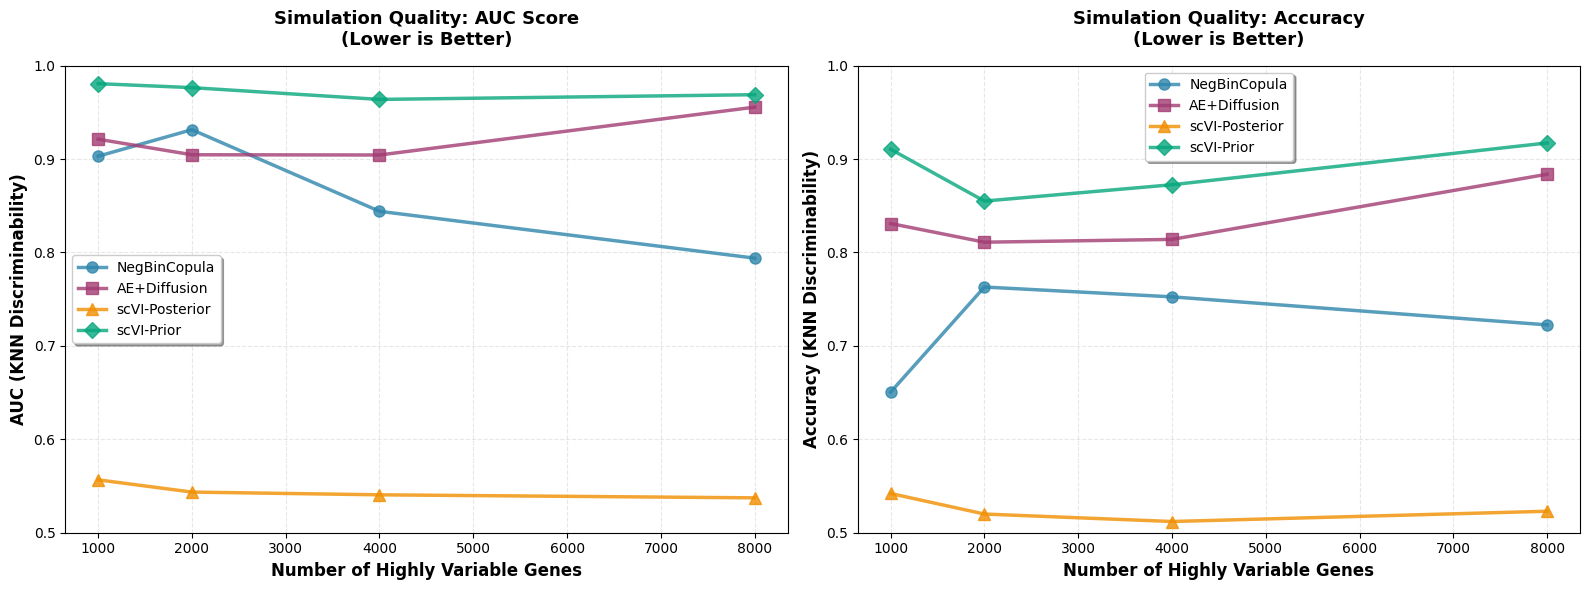

Plot saved to: sim_benchmarking_results/comparison_plot.png


In [5]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Color scheme for 4 methods
nbc_color = '#2E86AB'        # Blue for NegBinCopula
ae_diff_color = '#A23B72'    # Purple/Pink for AE+Diffusion
scvi_post_color = '#F18F01'  # Orange for scVI-Posterior
scvi_prior_color = '#06A77D'  # Green for scVI-Prior

# Plot 1: AUC vs Number of Genes
ax1.plot(n_genes, nbc_auc, marker='o', linewidth=2.5, markersize=8, 
         color=nbc_color, label='NegBinCopula', alpha=0.8)
ax1.plot(n_genes, ae_diff_auc, marker='s', linewidth=2.5, markersize=8, 
         color=ae_diff_color, label='AE+Diffusion', alpha=0.8)
ax1.plot(n_genes, scvi_post_auc, marker='^', linewidth=2.5, markersize=8, 
         color=scvi_post_color, label='scVI-Posterior', alpha=0.8)
ax1.plot(n_genes, scvi_prior_auc, marker='D', linewidth=2.5, markersize=8, 
         color=scvi_prior_color, label='scVI-Prior', alpha=0.8)

ax1.set_xlabel('Number of Highly Variable Genes', fontsize=12, fontweight='bold')
ax1.set_ylabel('AUC (KNN Discriminability)', fontsize=12, fontweight='bold')
ax1.set_title('Simulation Quality: AUC Score\n(Lower is Better)', fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', frameon=True, shadow=True, fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim([0.5, 1.0])

# Plot 2: Accuracy vs Number of Genes
ax2.plot(n_genes, nbc_acc, marker='o', linewidth=2.5, markersize=8, 
         color=nbc_color, label='NegBinCopula', alpha=0.8)
ax2.plot(n_genes, ae_diff_acc, marker='s', linewidth=2.5, markersize=8, 
         color=ae_diff_color, label='AE+Diffusion', alpha=0.8)
ax2.plot(n_genes, scvi_post_acc, marker='^', linewidth=2.5, markersize=8, 
         color=scvi_post_color, label='scVI-Posterior', alpha=0.8)
ax2.plot(n_genes, scvi_prior_acc, marker='D', linewidth=2.5, markersize=8, 
         color=scvi_prior_color, label='scVI-Prior', alpha=0.8)

ax2.set_xlabel('Number of Highly Variable Genes', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (KNN Discriminability)', fontsize=12, fontweight='bold')
ax2.set_title('Simulation Quality: Accuracy\n(Lower is Better)', fontsize=13, fontweight='bold', pad=15)
ax2.legend(loc='best', frameon=True, shadow=True, fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

print("Plot saved to: sim_benchmarking_results/comparison_plot.png")

## Interpretation

**Lower discriminability scores indicate better simulation quality** (harder to distinguish real from synthetic data).

- **AUC = 0.5 / Accuracy = 0.5**: Perfect simulation (indistinguishable from real data)
- **AUC = 1.0 / Accuracy = 1.0**: Poor simulation (easily distinguishable from real data)

The plots show how simulation quality changes as we increase the number of highly variable genes used in the analysis.

In [6]:
# Print summary statistics
def print_stats(name, auc_list, acc_list):
    # Filter out NaN values
    auc_valid = [x for x in auc_list if not np.isnan(x)]
    acc_valid = [x for x in acc_list if not np.isnan(x)]
    
    if len(auc_valid) == 0:
        print(f"{name}: No valid results")
        return
    
    print(f"\n{name}:")
    print(f"  AUC - Mean: {np.mean(auc_valid):.4f}, Std: {np.std(auc_valid):.4f}")
    print(f"  Acc - Mean: {np.mean(acc_valid):.4f}, Std: {np.std(acc_valid):.4f}")
    print(f"  Best AUC: {min(auc_valid):.4f} at {n_genes[auc_list.index(min(auc_valid))]} genes")
    print(f"  Best Acc: {min(acc_valid):.4f} at {n_genes[acc_list.index(min(acc_valid))]} genes")

print("="*70)
print("SUMMARY STATISTICS")
print("="*70)

print_stats("NegBinCopula", nbc_auc, nbc_acc)
print_stats("AE+Diffusion", ae_diff_auc, ae_diff_acc)
print_stats("scVI-Posterior", scvi_post_auc, scvi_post_acc)
print_stats("scVI-Prior", scvi_prior_auc, scvi_prior_acc)

print("\n" + "="*70)

SUMMARY STATISTICS

NegBinCopula:
  AUC - Mean: 0.8681, Std: 0.0532
  Acc - Mean: 0.7221, Std: 0.0439
  Best AUC: 0.7939 at 8000 genes
  Best Acc: 0.6505 at 1000 genes

AE+Diffusion:
  AUC - Mean: 0.9214, Std: 0.0209
  Acc - Mean: 0.8349, Std: 0.0292
  Best AUC: 0.9043 at 4000 genes
  Best Acc: 0.8110 at 2000 genes

scVI-Posterior:
  AUC - Mean: 0.5445, Std: 0.0073
  Acc - Mean: 0.5242, Std: 0.0110
  Best AUC: 0.5373 at 8000 genes
  Best Acc: 0.5120 at 4000 genes

scVI-Prior:
  AUC - Mean: 0.9725, Std: 0.0065
  Acc - Mean: 0.8888, Std: 0.0259
  Best AUC: 0.9638 at 4000 genes
  Best Acc: 0.8550 at 2000 genes



In [7]:
# Create a detailed comparison table
df = pd.DataFrame({
    'N_Genes': n_genes,
    'NBC_AUC': nbc_auc,
    'NBC_Acc': nbc_acc,
    'AE+Diff_AUC': ae_diff_auc,
    'AE+Diff_Acc': ae_diff_acc,
    'scVI_Post_AUC': scvi_post_auc,
    'scVI_Post_Acc': scvi_post_acc,
    'scVI_Prior_AUC': scvi_prior_auc,
    'scVI_Prior_Acc': scvi_prior_acc
})

print("\nDetailed Comparison Table:")
print("(Lower scores = better simulation quality)")
print(df.to_string(index=False))


Detailed Comparison Table:
(Lower scores = better simulation quality)
 N_Genes  NBC_AUC  NBC_Acc  AE+Diff_AUC  AE+Diff_Acc  scVI_Post_AUC  scVI_Post_Acc  scVI_Prior_AUC  scVI_Prior_Acc
    1000 0.903017   0.6505     0.921252      0.83100       0.556609          0.542        0.980721         0.91050
    2000 0.931437   0.7630     0.904594      0.81100       0.543502          0.520        0.976442         0.85500
    4000 0.844063   0.7525     0.904341      0.81400       0.540574          0.512        0.963832         0.87250
    8000 0.793916   0.7225     0.955578      0.88375       0.537340          0.523        0.968885         0.91725


In [8]:
# Rank methods by average performance
print("\n" + "="*70)
print("METHOD RANKING BY AVERAGE AUC (Lower is Better)")
print("="*70)

methods = {
    'NegBinCopula': nbc_auc,
    'AE+Diffusion': ae_diff_auc,
    'scVI-Posterior': scvi_post_auc,
    'scVI-Prior': scvi_prior_auc
}

rankings = []
for name, scores in methods.items():
    valid_scores = [x for x in scores if not np.isnan(x)]
    if len(valid_scores) > 0:
        rankings.append((name, np.mean(valid_scores)))

rankings.sort(key=lambda x: x[1])

for i, (name, avg_auc) in enumerate(rankings, 1):
    print(f"{i}. {name:<20} Average AUC: {avg_auc:.4f}")

print("\nBest performer: " + rankings[0][0])


METHOD RANKING BY AVERAGE AUC (Lower is Better)
1. scVI-Posterior       Average AUC: 0.5445
2. NegBinCopula         Average AUC: 0.8681
3. AE+Diffusion         Average AUC: 0.9214
4. scVI-Prior           Average AUC: 0.9725

Best performer: scVI-Posterior
